In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
%matplotlib inline

In [29]:
df = sns.load_dataset("penguins")
print("Shape:", df.shape)
df.head()

Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


In [31]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [32]:
df_clean = df.dropna()

df_clean = pd.get_dummies(df_clean, columns=['species', 'island', 'sex'], drop_first=True)

print("Shape after cleaning:", df_clean.shape)
df_clean.head()

Shape after cleaning: (333, 9)


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_Chinstrap,species_Gentoo,island_Dream,island_Torgersen,sex_Male
0,39.1,18.7,181.0,3750.0,False,False,False,True,True
1,39.5,17.4,186.0,3800.0,False,False,False,True,False
2,40.3,18.0,195.0,3250.0,False,False,False,True,False
4,36.7,19.3,193.0,3450.0,False,False,False,True,False
5,39.3,20.6,190.0,3650.0,False,False,False,True,True


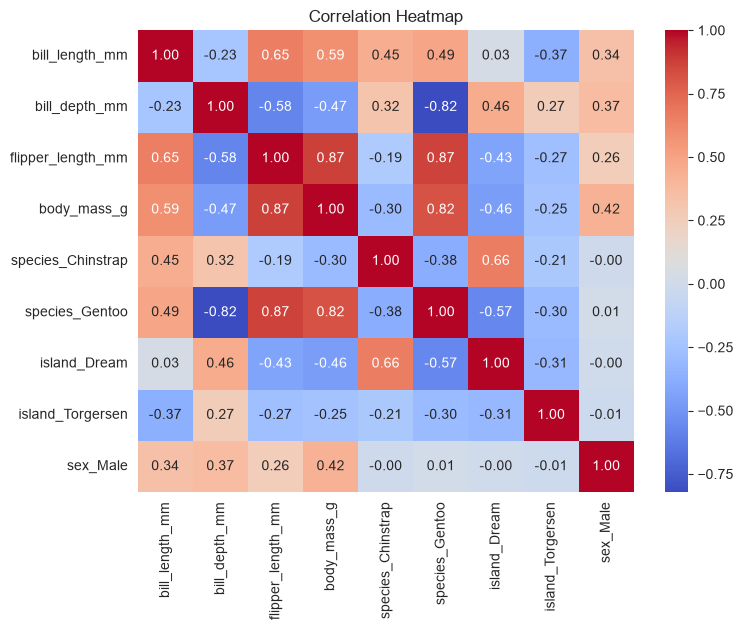

In [33]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [34]:
X = df_clean.drop(columns=["body_mass_g"])
y = df_clean["body_mass_g"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Training set size: (266, 8)
Testing set size: (67, 8)


In [35]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

In [36]:
bagging_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
    n_estimators=300,
    max_samples=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)

In [37]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

In [38]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

results = {
    "Linear Regression": evaluate(y_test, y_pred_lr),
    "Bagging Regressor": evaluate(y_test, y_pred_bagging),
    "XGBoost (Boosting)": evaluate(y_test, y_pred_xgb),
}

results_df = pd.DataFrame(results, index=["MAE", "RMSE", "R2"]).T
results_df = results_df.round(3)
results_df

,MAE,RMSE,R2
Linear Regression,196.209,255.749,0.896
Bagging Regressor,232.124,283.795,0.872
XGBoost (Boosting),259.339,316.160,0.841


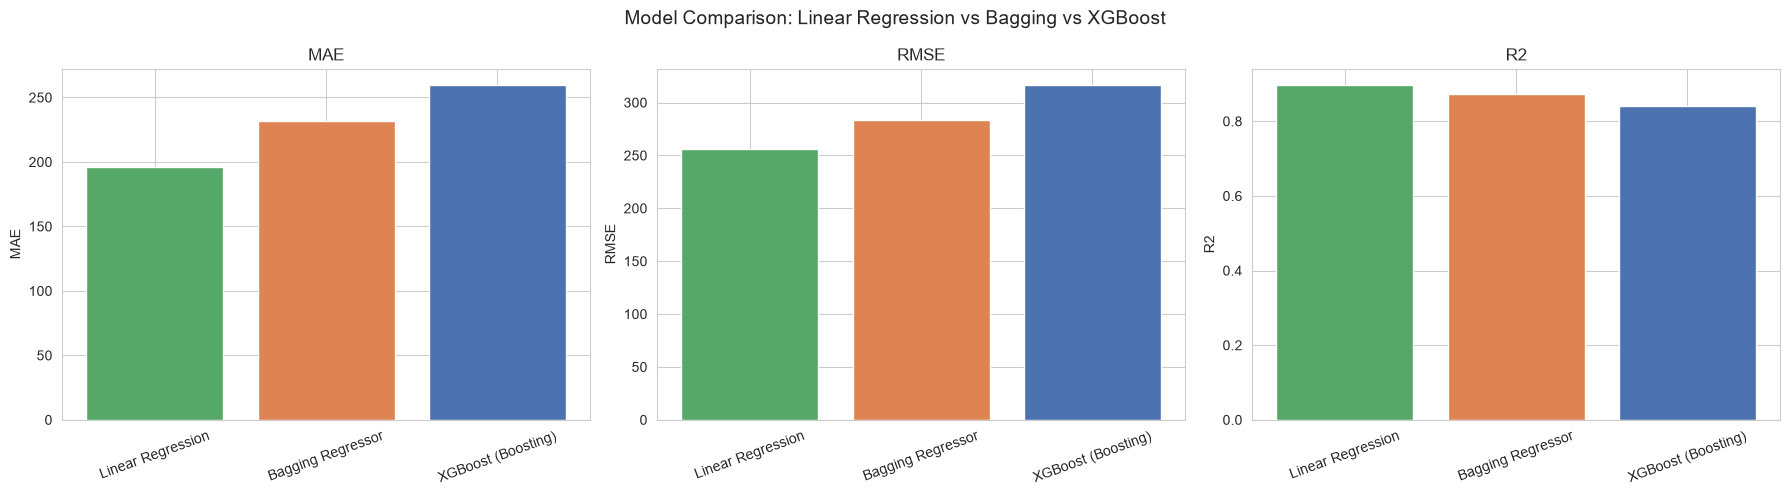

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ["MAE", "RMSE", "R2"]
colors = ["#55A868", "#DD8452", "#4C72B0"]

for ax, metric in zip(axes, metrics):
    ax.bar(results_df.index, results_df[metric], color=colors)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Model Comparison: Linear Regression vs Bagging vs XGBoost", fontsize=14)
plt.tight_layout()
plt.show()

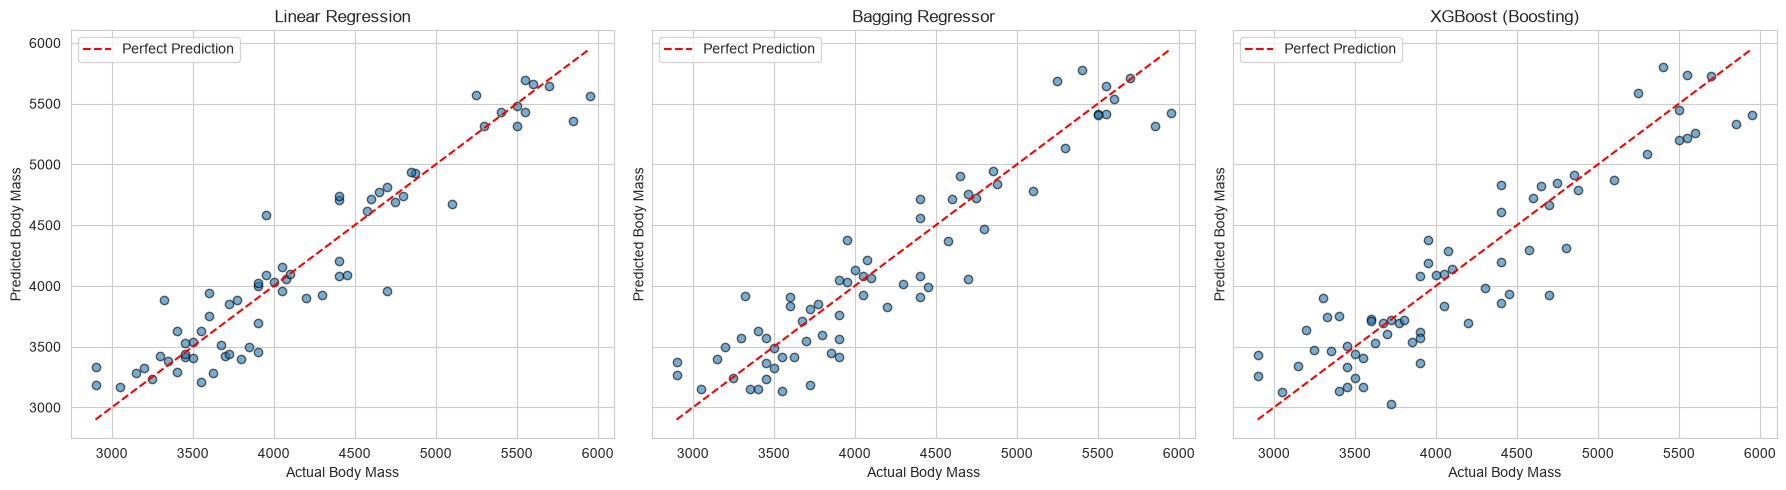

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
preds = {
    "Linear Regression": y_pred_lr,
    "Bagging Regressor": y_pred_bagging,
    "XGBoost (Boosting)": y_pred_xgb,
}

for ax, (name, pred) in zip(axes, preds.items()):
    ax.scatter(y_test, pred, alpha=0.6, edgecolor="k")
    lims = [y_test.min(), y_test.max()]
    ax.plot(lims, lims, "r--", label="Perfect Prediction")
    ax.set_title(name)
    ax.set_xlabel("Actual Body Mass")
    ax.set_ylabel("Predicted Body Mass")
    ax.legend()

plt.tight_layout()
plt.show()